In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:

import os
import time
import warnings
from datetime import datetime, date
from pathlib import Path

import gymnasium as gym
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gymnasium import spaces
from IPython.display import clear_output
from scipy.special import erfc
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from tqdm import tqdm


In [14]:
# Define gap widths
gaps = np.linspace(6, 14, 5).astype(int) 

# Load and process all info matrices
info_matrices = []
masked_info_matrices = []

for gap in gaps:
    # Load info matrix
    info_matrix = np.load(f'new_info_matrix_hres_{gap}.npy')[:,:-10]
    info_matrices.append(info_matrix)
    
    # Create mask (mimic animal cannot see well)
    mask = np.ones_like(info_matrix)
    # Create a vertical gradient (1.0 at top, decreasing to 0.0 at bottom)
    gradient = np.linspace(0.0, 1., info_matrix.shape[1])
    for i in range(info_matrix.shape[1]):
        mask[:, i] = gradient[i]
    
    # Apply the mask to darken the bottom gradually
    masked_info_matrix = info_matrix * mask
    masked_info_matrices.append(masked_info_matrix)

print(f"Loaded {len(info_matrices)} info matrices")

colors_multi_aperture = ["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"]

Loaded 5 info matrices


In [15]:

class MouseNavigationEnv(gym.Env):
    """
    Mouse Navigation Environment with Left and Right Visual Areas.

    The mouse navigates a 2D arena to find the correct reward port based on
    accumulated left and right visual information, affected by observation noise.
    """

    def __init__(self, noise, info_matrix, nx=60, ny=50, max_v=4, i_threshold=20,
                 vcost=0.01, wcost=0.01, timecost=0.01, info_scale=1 / 20,
                 max_steps=100, reward_magnitude=1):
        super(MouseNavigationEnv, self).__init__()

        # Arena dimensions
        self.nx = nx
        self.ny = ny
        self.max_v = max_v
        self.i_threshold = i_threshold

        # Observation noise (standard deviation)
        self.noise = noise

        # Costs
        self.vcost = vcost
        self.wcost = wcost
        self.timecost = timecost
        self.info_scale = info_scale
        self.reward_magnitude = reward_magnitude

        self.info_matrix = info_matrix

        # Port locations
        self.left_port_x = 0
        self.right_port_x = nx - 1
        self.port_y = ny - 1

        # Correct port will be randomly selected in reset()
        self.correct_port_x = None

        # Maximum steps per episode
        self.max_steps = max_steps

        # Action space: Acceleration in x and y directions [-3, -2, -1, 0, 1, 2, 3]
        self.action_space = spaces.MultiDiscrete([7, 7])

        # Observation space: [x, y, vx, vy, left_info, right_info]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1, -1]),
            high=np.array([1, 1, 1, 1, 1]), # normalize
            # high=np.array([nx - 1, ny - 1, max_v, max_v, 1]),
            dtype=np.float32
        )

        # Initialize state
        self.reset()

    def reset(self, seed=None, options=None):
        """Reset the environment to the starting state."""
        super().reset(seed=seed)

        # Start at the bottom center
        self.x = self.nx // 2
        self.y = 0

        # Start with zero velocity
        self.vx = 0
        self.vy = 0

        # Reset accumulated information
        self.cumulative_info = 0

        # Reset step counter
        self.steps = 0

        if options is not None:
            self.correct_port_x = options
        else:
            # Randomly select the correct port (left or right)
            self.correct_port_x = np.random.choice([self.left_port_x, self.right_port_x])

        # Current state
        self._update_state()

        return self.state, {}

    def _update_state(self):
        """Update the state vector."""
        if self.correct_port_x == 0:
            rewardp=self._success_prob_from_info(self.cumulative_info)*2-1
        else:
            rewardp=(self._success_prob_from_info(-self.cumulative_info)*2-1)*-1
        self.state = np.array([
            self.x/(self.nx-1), 
            self.y/(self.ny-1), 
            self.vx/self.max_v, 
            self.vy/self.max_v,
            rewardp
        ], dtype=np.float32)

    def _get_area_info_at_position(self, x, y, testing=False):
        """Get left and right area information at the given position with noise."""
        # Convert to integer indices and clip to bounds
        x_idx = max(0, min(int(x), self.nx - 1))
        y_idx = max(0, min(int(y), self.ny - 1))

        # Get raw values from matrices
        raw = self.info_matrix[x_idx, y_idx] * self.info_scale

        # Add observation noise. the noisy can be no info at all, or can by no noise (full info at the location)
        # we want: less info more chance to not observe anyything
        # noisy = (raw - np.max(self.info_matrix)/3*self.noise*(np.random.uniform(0, 1)))
        p=raw/np.max(self.info_matrix)
        noisy=(p-np.random.uniform(0, 1*self.noise))
        noisy = max(0, noisy)

        if testing:
            noisy = raw
        if self.correct_port_x == 0:
            return noisy
        else:
            return -noisy

    def _success_prob_from_info(self, info_val):
        """
        Calculate success probability based on accumulated left and right information.
        Higher difference between the correct choice and incorrect choice
        leads to higher success probability.
        """

        info_val = abs(info_val)

        # Use the erfc function: (1/2) * erfc(-sqrt(J/2))
        return 0.5 * erfc(-np.sqrt(info_val / 2))

    def step(self, action, testing=False):
        """
        Take a step in the environment based on the action.

        Args:
            action: [ax, ay] representing accelerations in x and y directions
                   Each element is in range [0, 6] which maps to [-3, -2, -1, 0, 1, 2, 3]

        Returns:
            (state, reward, done, truncated, info)
        """
        reward=0

        # Increment step counter
        self.steps += 1

        # Map action to acceleration
        ax = action[0]-3
        ay = action[1]-3
        # print(ax,ay)
        # Calculate next velocity
        next_vx = self.vx + ax
        next_vy = self.vy + ay
        # print(next_vx,next_vy)
        # Check velocity constraints
        speed = np.sqrt(next_vx**2 + next_vy**2)
        if speed >= self.max_v:
            # Scale down the velocity to max_v
            scaling_factor = (self.max_v - 0.1) / speed
            next_vx = next_vx * scaling_factor
            next_vy = next_vy * scaling_factor

        # Store old position for reward calculation
        old_x, old_y = self.x, self.y

        # Update position
        self.x += next_vx
        self.y += next_vy

        # wall penalty
        wall_penalty = 0
        # original_x, original_y = self.x, self.y

        # Check if hitting walls and apply penalty
        if self.x < 0 or self.x >= self.nx:
            wall_penalty -= 0  # Adjust penalty amount as needed
        if self.y < 0 or self.y >= self.ny:
            wall_penalty -= 0
        reward += wall_penalty


        # Clip position to arena boundaries
        self.x = max(0, min(self.x, self.nx - 1))
        self.y = max(0, min(self.y, self.ny - 1))

        # Check if approaching a port and enforce horizontal approach
        approaching_port = (self.y >= self.port_y - abs(next_vy) and
                            (abs(self.x - self.left_port_x) <= abs(next_vx) or
                            abs(self.x - self.right_port_x) <= abs(next_vx)))

        if approaching_port:
            # Force horizontal approach by zeroing out vertical velocity
            self.vy = 0
        else:
            self.vy = next_vy

        self.vx = next_vx

        # Accumulate left and right information at current position
        info_gain = self._get_area_info_at_position(old_x, old_y, testing)
        self.cumulative_info += info_gain

        # Calculate costs
        velocity_cost = np.sqrt(self.vx**2 + self.vy**2) * self.vcost
        accel_cost = np.sqrt(ax**2 + ay**2) * self.wcost
        step_cost = -velocity_cost - accel_cost - self.timecost

        # Check if done
        at_left_port = (round(self.y) == self.port_y and round(self.x) == self.left_port_x)
        at_right_port = (round(self.y) == self.port_y and round(self.x) == self.right_port_x)
        at_port = at_left_port or at_right_port

        stopped = (abs(self.vx) < 0.01 and abs(self.vy) < 0.01 and self.steps > 1)
        reached_steps_limit = self.steps >= self.max_steps

        done = at_port or stopped or reached_steps_limit

        # Calculate reward
        reward += step_cost  # Always apply movement costs
        success_prob = self._success_prob_from_info(self.cumulative_info)
        if at_port:
            # Calculate success probability based on accumulated information
            

            # Check if the mouse chose the correct port
            correct_choice = ((at_left_port and self.correct_port_x == self.left_port_x) or
                              (at_right_port and self.correct_port_x == self.right_port_x))

            # Stochastically determine success based on accumulated information
            if correct_choice:
                # Success with probability based on accumulated info
                reward_outcome = success_prob * self.reward_magnitude
            else:
                # Failure with probability based on accumulated info (incorrect choice)
                # reward_outcome = 1 - success_prob*self.reward_magnitude
                reward_outcome = -success_prob * self.reward_magnitude*5

            reward += reward_outcome
        elif stopped:
            # Penalty for stopping without reaching a port
            reward -= 0.5 * self.reward_magnitude
        elif reached_steps_limit:
            # Small penalty for timeout
            reward -= 0.25 * self.reward_magnitude

        # if know which port, reward for going toward it
        # if success_prob>0.3:
        #     # print(success_prob, self.vx, np.sign(self.cumulative_info), success_prob*self.vx*np.sign(self.cumulative_info)*-1)
        #     away_punish=success_prob*self.vx*np.sign(self.cumulative_info)*-1*0.05
        #     reward+=min(0,away_punish)

        # Update state
        self._update_state()

        # Info dictionary for additional data
        info = {
            'position': (self.x, self.y),
            'velocity': (self.vx, self.vy),
            'cumulative_info': self.cumulative_info,
            'step_cost': step_cost,
            'at_port': at_port,
            'correct_port': 'left' if self.correct_port_x == self.left_port_x else 'right',
            'chosen_port': 'left' if at_left_port else ('right' if at_right_port else None),
            'success_prob': self._success_prob_from_info(
                self.cumulative_info
            ),
            'info_gain': info_gain,
        }

        return self.state, reward, done, False, info



In [16]:

# Create environments for each gap width
envs = []
for i, gap in enumerate(gaps):
    env = MouseNavigationEnv(
        info_matrix=info_matrices[i],
        nx=60, ny=50, max_v=4, i_threshold=5, 
        noise=0.3, 
        vcost=0.01, 
        wcost=0.01, 
        timecost=0.001, 
        info_scale=0.3,
        max_steps=200, 
        reward_magnitude=3
    )
    envs.append(env)
    print(f"Created environment for gap width {gap}")

# # testing,  Load models for each gap width
# models = []
# for gap in gaps:
#     model_path = f"./mouse_navigation_modelw{gap}"
#     try:
#         model = PPO.load(model_path)
#         models.append(model)
#         print(f"Loaded model for gap width {gap}")
#     except Exception as e:
#         print(f"Warning: Could not load model for gap width {gap}: {e}")
#         models.append(None)


models = []
for i, gap in enumerate(gaps):
    model=PPO("MlpPolicy", envs[i], verbose=0, 
            learning_rate=0.0001,
            n_steps=1024,
            batch_size=256, 
            gamma=0.99,
            ent_coef=0.05,  # Encourage exploration
            clip_range=0.2,
            # n_epochs=10,    # More updates per batch
            gae_lambda=0.95)
    models.append(model)


Created environment for gap width 6
Created environment for gap width 8
Created environment for gap width 10
Created environment for gap width 12
Created environment for gap width 14


In [24]:
def compare_models_multi_gaps(models, envs, info_matrices, gaps, 
                             trials_per_condition=30, 
                             colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                             save_path=None, 
                             figure_title='Multi-Gap Model Comparison - Average Trajectories'):
    """
    Compare multiple models across different gap widths with trajectory visualization.
    
    Parameters:
    - models: List of trained models for each gap
    - envs: List of environments for each gap
    - info_matrices: List of information matrices for each gap
    - gaps: Array of gap widths
    - trials_per_condition: Number of trials to run for each condition (left/right)
    - colors_multi_aperture: Colors for each gap width
    - save_path: Optional path to save the figure
    - figure_title: Title for the figure
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    
    # Function to interpolate trajectories
    def interpolate_trajectory(x, y, n_points):
        """Interpolate trajectory to fixed number of points"""
        from scipy.interpolate import interp1d
        if len(x) < 2:
            return np.array([x[0]] * n_points), np.array([y[0]] * n_points)
        
        t_orig = np.linspace(0, 1, len(x))
        t_new = np.linspace(0, 1, n_points)
        
        fx = interp1d(t_orig, x, kind='linear')
        fy = interp1d(t_orig, y, kind='linear')
        
        return fx(t_new), fy(t_new)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Store all model data for statistics
    all_model_data = []
    legend_handles = []
    legend_labels = []
    
    # Line styles for different gaps (cycle through if more gaps than styles)
    line_styles = ['-']*5    
    # Process each gap/model combination
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            print(f"Skipping gap {gap} - model not loaded")
            continue
            
        print(f"Running trials for gap width {gap}...")
        
        # Run trials for this model
        model_data = run_model_trials(model, env, trials_per_condition)
        all_model_data.append((model_data, gap))
        
        # Use the same color for both left and right trajectories of this gap
        gap_color = colors_multi_aperture[i % len(colors_multi_aperture)]
        colors_choice = [gap_color, gap_color]  # Same color for left/right
        linestyle = line_styles[i % len(line_styles)]
        
        # Plot trajectories for this gap
        plot_model_trajectories_multi_gap(
            model_data, colors_choice, alpha=0.3, linewidth=0.8, 
            linestyle=linestyle, interpolate_trajectory=interpolate_trajectory,
            gap_width=gap, gap_color=gap_color
        )
        
        # Add to legend (one entry per gap)
        legend_handles.append(Line2D([0], [0], color=gap_color, linewidth=2, linestyle=linestyle))
        legend_labels.append(f'Gap {gap}')
    
    # Create legend
    plt.legend(legend_handles, legend_labels, loc='upper right')
    
    # Styling
    plt.xlabel('x position (cm)')
    plt.ylabel('y position (cm)')
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xticks([])
    plt.yticks([])
    
    # Add scale bar
    x0, y0 = -15, -5
    ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
    ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)
    
    # Add text labels
    ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
    ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')
    
    ax.set_title(figure_title)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print_multi_gap_comparison_stats(all_model_data)


def plot_model_trajectories_multi_gap(model_data, colors_choice, alpha=0.3, linewidth=0.8, 
                                     linestyle='-', interpolate_trajectory=None, 
                                     gap_width=None, gap_color=None):
    """Plot trajectories for a single model/gap with consistent styling"""
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Interpolate trajectories
    left_interp_x, left_interp_y = [], []
    for x, y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        left_interp_x.append(interp_x)
        left_interp_y.append(interp_y)
    
    right_interp_x, right_interp_y = [], []
    for x, y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        right_interp_x.append(interp_x)
        right_interp_y.append(interp_y)
    
    # Calculate means and stds
    left_x_array = np.array(left_interp_x)
    left_y_array = np.array(left_interp_y)
    left_mean_x = np.mean(left_x_array, axis=0)
    left_std_x = np.std(left_x_array, axis=0)
    left_mean_y = np.mean(left_y_array, axis=0)
    left_std_y = np.std(left_y_array, axis=0)
    
    right_x_array = np.array(right_interp_x)
    right_y_array = np.array(right_interp_y)
    right_mean_x = np.mean(right_x_array, axis=0)
    right_std_x = np.std(right_x_array, axis=0)
    right_mean_y = np.mean(right_y_array, axis=0)
    right_std_y = np.std(right_y_array, axis=0)
    
    # # Plot individual trajectories (lighter)
    # for positions_x, positions_y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
    #     plt.plot(positions_x, positions_y, color=gap_color, alpha=alpha*0.6, 
    #             linewidth=linewidth*0.7, linestyle=linestyle)
    
    # for positions_x, positions_y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
    #     plt.plot(positions_x, positions_y, color=gap_color, alpha=alpha*0.6, 
    #             linewidth=linewidth*0.7, linestyle=linestyle)
    
    # Plot mean trajectories (thicker, more opaque)
    plt.plot(left_mean_x, left_mean_y, color=gap_color, linewidth=2.5, 
            linestyle=linestyle, alpha=0.9)
    plt.plot(right_mean_x, right_mean_y, color=gap_color, linewidth=2.5, 
            linestyle=linestyle, alpha=0.9)
    
    # Add error bands (lighter)
    plt.fill_between(left_mean_x, 
                    left_mean_y - left_std_y, 
                    left_mean_y + left_std_y, 
                    alpha=0.15, color=gap_color)
    plt.fill_between(right_mean_x, 
                    right_mean_y - right_std_y, 
                    right_mean_y + right_std_y, 
                    alpha=0.15, color=gap_color)


def run_model_trials(model, env, trials_per_condition):
    """Run trials for a single model and return trajectory data"""
    import warnings
    import numpy as np
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Storage for trial data
        left_trial_positions_x = []
        left_trial_positions_y = []
        left_trial_results = []
        left_trial_rewards = []
        
        right_trial_positions_x = []
        right_trial_positions_y = []
        right_trial_results = []
        right_trial_rewards = []
        
        # Run left port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=0)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
            left_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            left_trial_results.append(result)
        
        # Run right port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=59)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
            right_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            right_trial_results.append(result)
    
    return {
        'left_positions_x': left_trial_positions_x,
        'left_positions_y': left_trial_positions_y,
        'left_results': left_trial_results,
        'left_rewards': left_trial_rewards,
        'right_positions_x': right_trial_positions_x,
        'right_positions_y': right_trial_positions_y,
        'right_results': right_trial_results,
        'right_rewards': right_trial_rewards
    }


def print_multi_gap_comparison_stats(all_model_data):
    """Print comparison statistics between multiple gap models"""
    import numpy as np
    
    print(f"\n=== Multi-Gap Model Comparison Statistics ===")
    
    for model_data, gap in all_model_data:
        # Calculate success rates
        left_success = sum(1 for r in model_data['left_results'] if r == "Success") / len(model_data['left_results'])
        right_success = sum(1 for r in model_data['right_results'] if r == "Success") / len(model_data['right_results'])
        overall_success = (left_success + right_success) / 2
        
        print(f"Gap {gap}:")
        print(f"  Left trials: Success Rate = {left_success:.2f}, Avg Reward = {np.mean(model_data['left_rewards']):.2f}")
        print(f"  Right trials: Success Rate = {right_success:.2f}, Avg Reward = {np.mean(model_data['right_rewards']):.2f}")
        print(f"  Overall Success Rate = {overall_success:.2f}")
        print()



Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


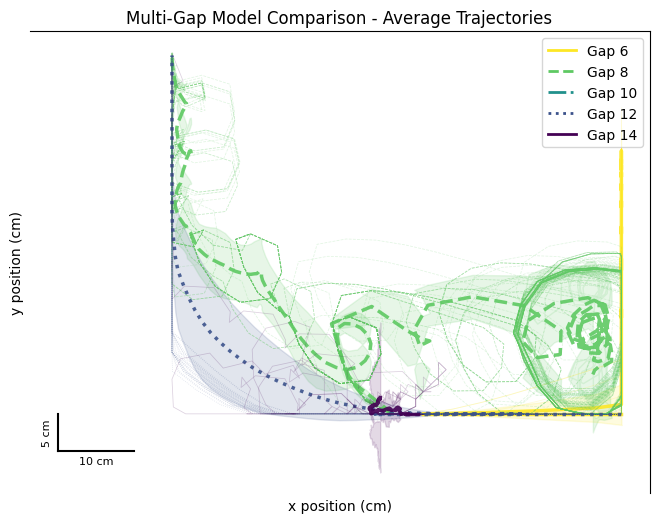


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 0.00, Avg Reward = -15.06
  Right trials: Success Rate = 0.00, Avg Reward = -15.06
  Overall Success Rate = 0.00

Gap 8:
  Left trials: Success Rate = 0.00, Avg Reward = -14.32
  Right trials: Success Rate = 0.00, Avg Reward = -14.96
  Overall Success Rate = 0.00

Gap 10:
  Left trials: Success Rate = 0.00, Avg Reward = -1.50
  Right trials: Success Rate = 0.00, Avg Reward = -1.50
  Overall Success Rate = 0.00

Gap 12:
  Left trials: Success Rate = 0.00, Avg Reward = -14.37
  Right trials: Success Rate = 0.00, Avg Reward = -19.04
  Overall Success Rate = 0.00

Gap 14:
  Left trials: Success Rate = 0.00, Avg Reward = -1.61
  Right trials: Success Rate = 0.00, Avg Reward = -5.02
  Overall Success Rate = 0.00



In [19]:
colors_multi_aperture = ["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"]
gaps = np.linspace(6, 14, 5).astype(int)  # [6, 8, 10, 12, 14]

compare_models_multi_gaps(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=22,
    colors_multi_aperture=colors_multi_aperture,
    save_path="multi_gap_comparison.svg"
)

# training

Output()


=== Epoch 1/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 1...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


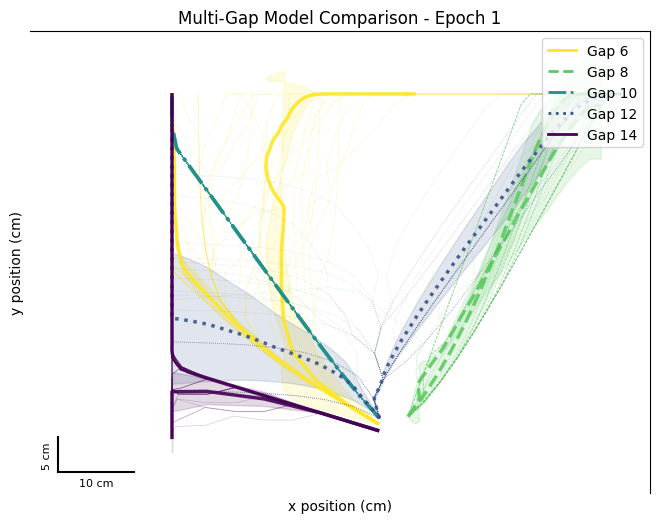

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 0.32
  Right trials: Success Rate = 0.41, Avg Reward = -8.75
  Overall Success Rate = 0.70

Gap 8:
  Left trials: Success Rate = 0.00, Avg Reward = -10.84
  Right trials: Success Rate = 1.00, Avg Reward = 0.49
  Overall Success Rate = 0.50

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 0.86
  Right trials: Success Rate = 0.00, Avg Reward = -11.55
  Overall Success Rate = 0.50

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = -2.02
  Right trials: Success Rate = 1.00, Avg Reward = 1.05
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 0.05
  Right trials: Success Rate = 0.00, Avg Reward = -13.50
  Overall Success Rate = 0.50

Epoch 1 completed!

=== Epoch 2/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 2...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


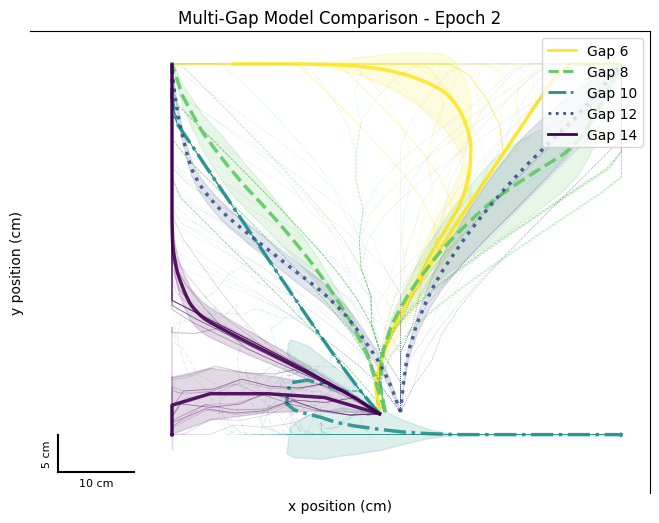

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 0.86, Avg Reward = -1.24
  Right trials: Success Rate = 1.00, Avg Reward = 0.46
  Overall Success Rate = 0.93

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 0.83
  Right trials: Success Rate = 1.00, Avg Reward = 0.65
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 0.82
  Right trials: Success Rate = 0.00, Avg Reward = -13.78
  Overall Success Rate = 0.50

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 0.71
  Right trials: Success Rate = 1.00, Avg Reward = 0.95
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 0.70
  Right trials: Success Rate = 0.00, Avg Reward = -14.16
  Overall Success Rate = 0.50

Epoch 2 completed!

=== Epoch 3/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 3...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


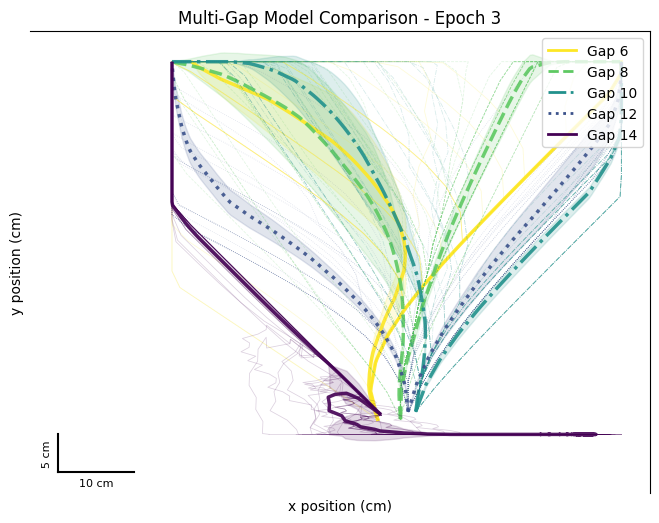

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 0.95, Avg Reward = 0.01
  Right trials: Success Rate = 1.00, Avg Reward = 0.65
  Overall Success Rate = 0.98

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 0.68
  Right trials: Success Rate = 1.00, Avg Reward = 0.78
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 0.77
  Right trials: Success Rate = 1.00, Avg Reward = 0.90
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 0.95
  Right trials: Success Rate = 1.00, Avg Reward = 1.37
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 0.75
  Right trials: Success Rate = 0.00, Avg Reward = -7.20
  Overall Success Rate = 0.50

Epoch 3 completed!

=== Epoch 4/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 4...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


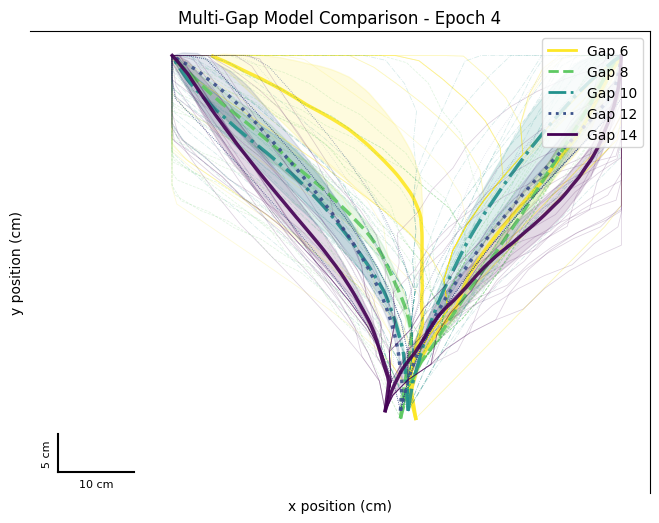

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 0.91, Avg Reward = -0.37
  Right trials: Success Rate = 1.00, Avg Reward = 0.63
  Overall Success Rate = 0.95

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 0.82
  Right trials: Success Rate = 1.00, Avg Reward = 1.07
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 0.97
  Right trials: Success Rate = 1.00, Avg Reward = 1.03
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.41
  Right trials: Success Rate = 1.00, Avg Reward = 1.42
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.15
  Right trials: Success Rate = 1.00, Avg Reward = 1.22
  Overall Success Rate = 1.00

Epoch 4 completed!

=== Epoch 5/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 5...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


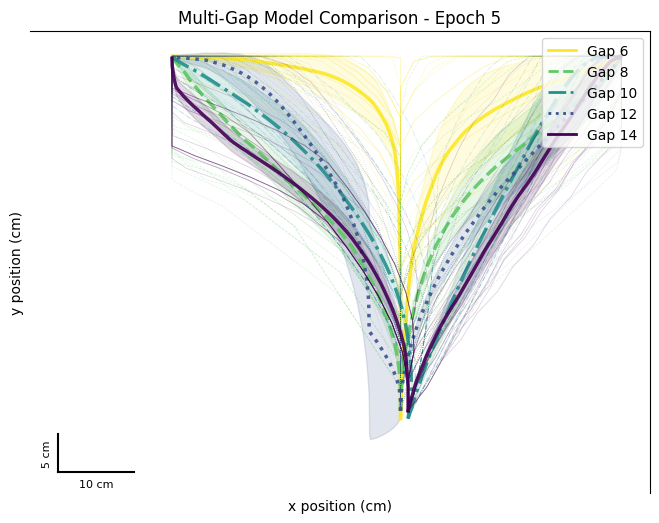

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.10
  Right trials: Success Rate = 1.00, Avg Reward = 1.01
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.02
  Right trials: Success Rate = 1.00, Avg Reward = 1.20
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.35
  Right trials: Success Rate = 1.00, Avg Reward = 1.10
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 0.86, Avg Reward = 0.44
  Right trials: Success Rate = 1.00, Avg Reward = 1.62
  Overall Success Rate = 0.93

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.06
  Right trials: Success Rate = 1.00, Avg Reward = 1.27
  Overall Success Rate = 1.00

Epoch 5 completed!

=== Epoch 6/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 6...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


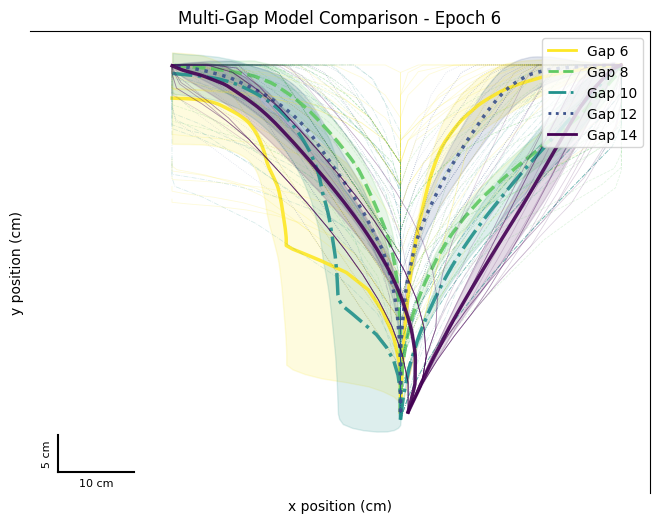

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 0.50, Avg Reward = -5.59
  Right trials: Success Rate = 1.00, Avg Reward = 1.06
  Overall Success Rate = 0.75

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.37
  Right trials: Success Rate = 1.00, Avg Reward = 1.29
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 0.73, Avg Reward = -1.53
  Right trials: Success Rate = 1.00, Avg Reward = 1.32
  Overall Success Rate = 0.86

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.69
  Right trials: Success Rate = 1.00, Avg Reward = 1.67
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.47
  Right trials: Success Rate = 1.00, Avg Reward = 1.32
  Overall Success Rate = 1.00

Epoch 6 completed!

=== Epoch 7/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 7...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


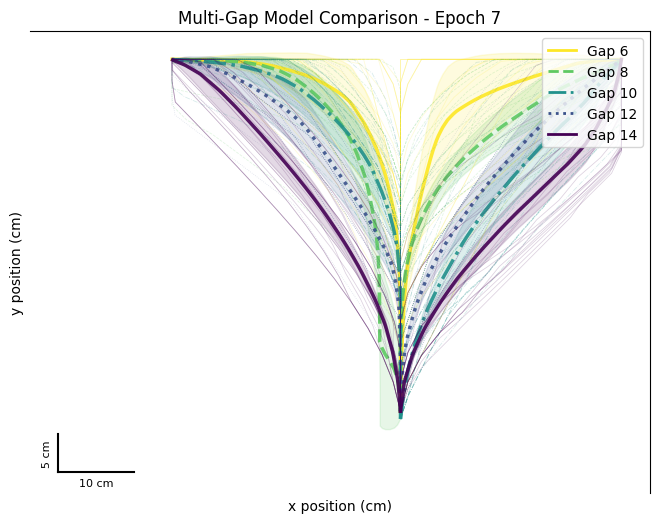

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.07
  Right trials: Success Rate = 1.00, Avg Reward = 1.14
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 0.91, Avg Reward = 0.44
  Right trials: Success Rate = 1.00, Avg Reward = 1.34
  Overall Success Rate = 0.95

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.60
  Right trials: Success Rate = 1.00, Avg Reward = 1.41
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.68
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.50
  Right trials: Success Rate = 1.00, Avg Reward = 1.49
  Overall Success Rate = 1.00

Epoch 7 completed!

=== Epoch 8/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 8...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


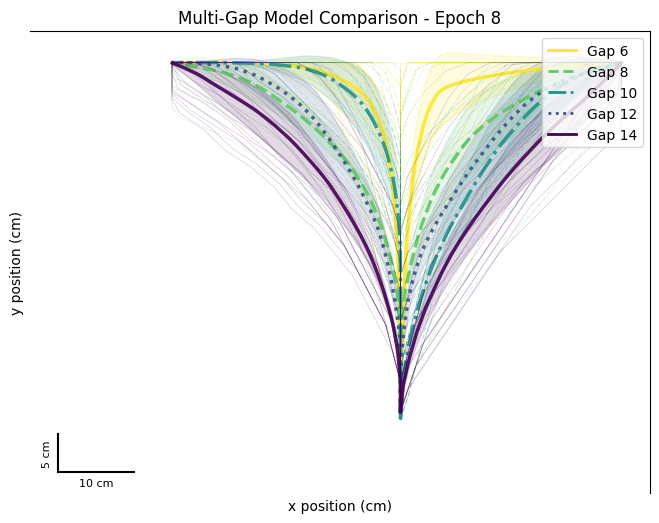

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.15
  Right trials: Success Rate = 1.00, Avg Reward = 1.16
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.38
  Right trials: Success Rate = 1.00, Avg Reward = 1.35
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.60
  Right trials: Success Rate = 1.00, Avg Reward = 1.46
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.66
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.65
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Epoch 8 completed!

=== Epoch 9/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 9...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


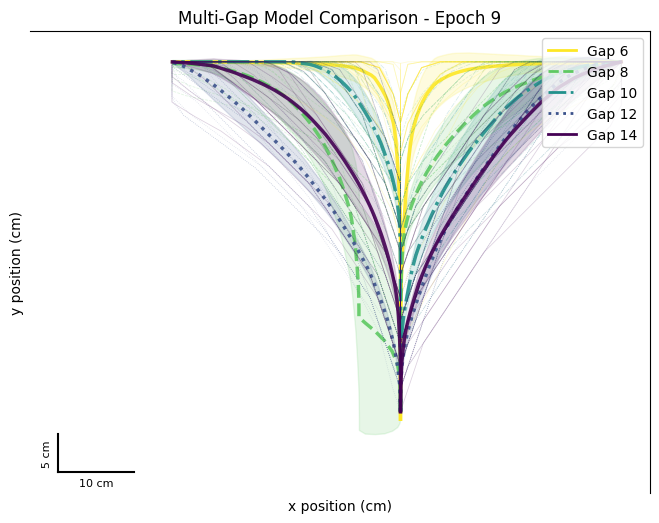

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.28
  Right trials: Success Rate = 1.00, Avg Reward = 1.20
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 0.82, Avg Reward = -0.50
  Right trials: Success Rate = 1.00, Avg Reward = 1.41
  Overall Success Rate = 0.91

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.69
  Right trials: Success Rate = 1.00, Avg Reward = 1.56
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.69
  Right trials: Success Rate = 1.00, Avg Reward = 1.65
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.71
  Right trials: Success Rate = 1.00, Avg Reward = 1.68
  Overall Success Rate = 1.00

Epoch 9 completed!

=== Epoch 10/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 10...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


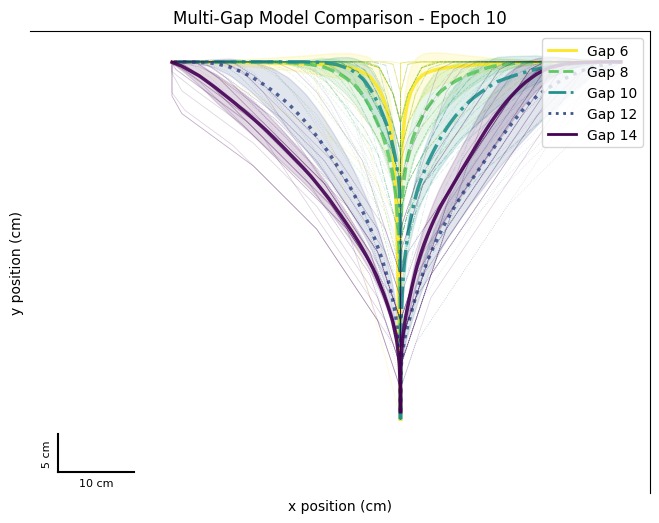

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.26
  Right trials: Success Rate = 1.00, Avg Reward = 1.33
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.44
  Right trials: Success Rate = 1.00, Avg Reward = 1.42
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.63
  Right trials: Success Rate = 1.00, Avg Reward = 1.59
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.69
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.70
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Epoch 10 completed!

=== Epoch 11/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 11...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


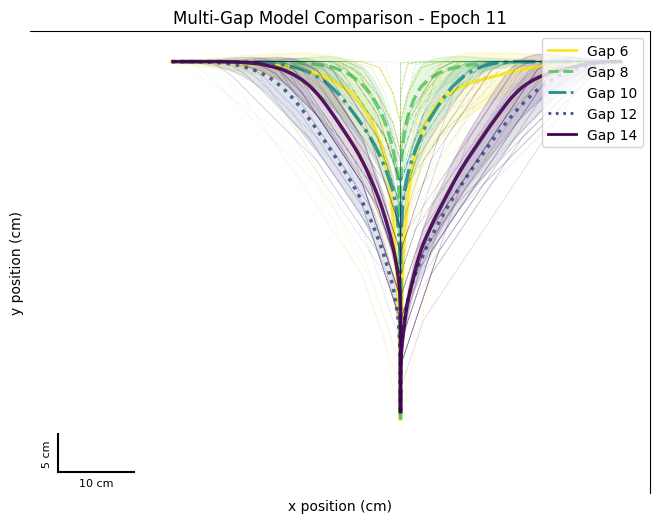

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.13
  Right trials: Success Rate = 1.00, Avg Reward = 1.14
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.47
  Right trials: Success Rate = 1.00, Avg Reward = 1.47
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.66
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.64
  Right trials: Success Rate = 1.00, Avg Reward = 1.68
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.74
  Right trials: Success Rate = 1.00, Avg Reward = 1.73
  Overall Success Rate = 1.00

Epoch 11 completed!

=== Epoch 12/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 12...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


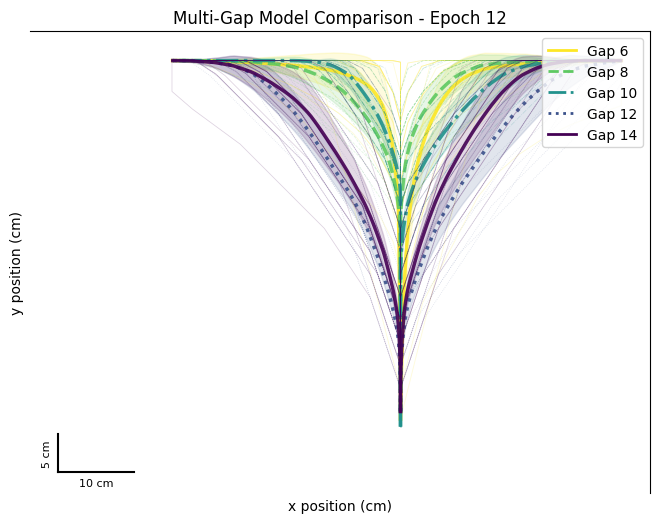

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.26
  Right trials: Success Rate = 1.00, Avg Reward = 1.14
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.46
  Right trials: Success Rate = 1.00, Avg Reward = 1.49
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.69
  Right trials: Success Rate = 1.00, Avg Reward = 1.63
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.68
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.75
  Right trials: Success Rate = 1.00, Avg Reward = 1.71
  Overall Success Rate = 1.00

Epoch 12 completed!

=== Epoch 13/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 13...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


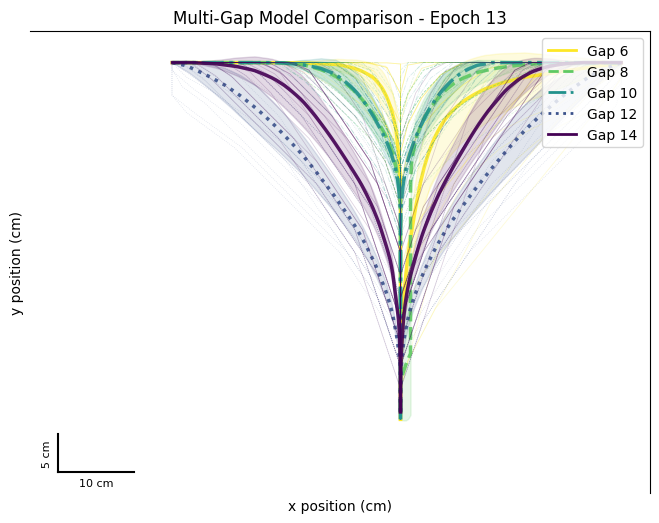

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.24
  Right trials: Success Rate = 1.00, Avg Reward = 1.14
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.51
  Right trials: Success Rate = 0.95, Avg Reward = 1.11
  Overall Success Rate = 0.98

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.66
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.64
  Right trials: Success Rate = 1.00, Avg Reward = 1.68
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.74
  Right trials: Success Rate = 1.00, Avg Reward = 1.73
  Overall Success Rate = 1.00

Epoch 13 completed!

=== Epoch 14/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 14...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


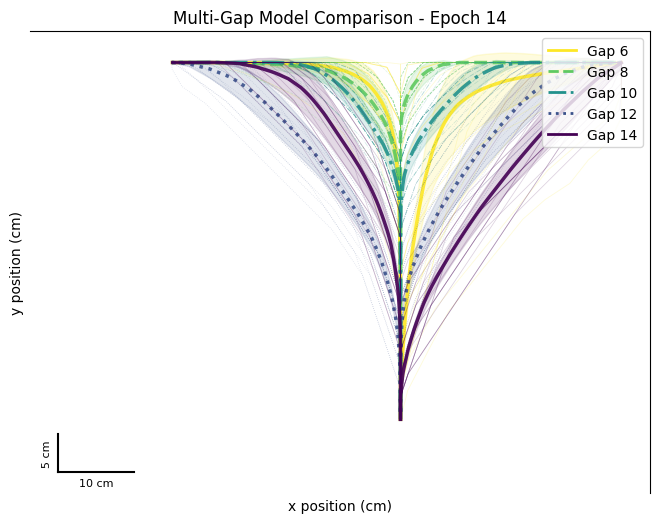

Output()


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.25
  Right trials: Success Rate = 1.00, Avg Reward = 1.15
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.53
  Right trials: Success Rate = 1.00, Avg Reward = 1.59
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.68
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.72
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.75
  Right trials: Success Rate = 1.00, Avg Reward = 1.75
  Overall Success Rate = 1.00

Epoch 14 completed!

=== Epoch 15/15 ===
Training gap 6 model...


Output()

Model for gap 6 saved to ./0630_mouse_navigation_modelw6
Training gap 8 model...


Output()

...

Output()

Model for gap 10 saved to ./0630_mouse_navigation_modelw10
Training gap 12 model...


Output()

Model for gap 12 saved to ./0630_mouse_navigation_modelw12
Training gap 14 model...


Model for gap 14 saved to ./0630_mouse_navigation_modelw14
Comparing all models after epoch 15...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


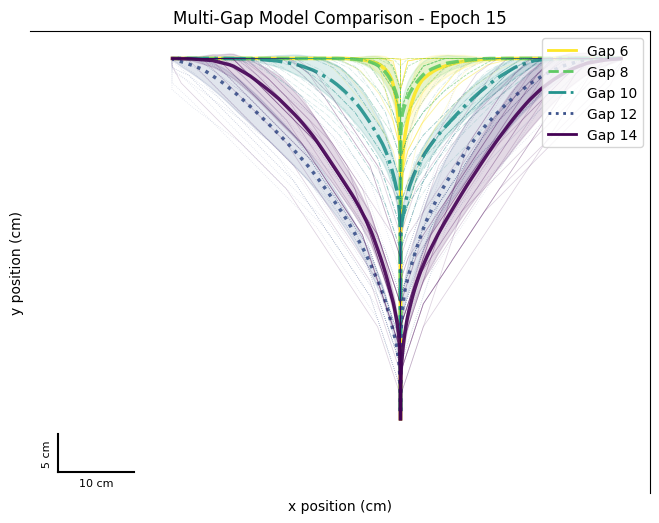


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.34
  Right trials: Success Rate = 1.00, Avg Reward = 1.28
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.58
  Right trials: Success Rate = 1.00, Avg Reward = 1.56
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.65
  Right trials: Success Rate = 1.00, Avg Reward = 1.67
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.68
  Right trials: Success Rate = 1.00, Avg Reward = 1.69
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.73
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Epoch 15 completed!


In [20]:

# Training loop
for epoch in range(15):
    print(f"\n=== Epoch {epoch + 1}/15 ===")
    
    # Train all models
    for i, (model, gap) in enumerate(zip(models, gaps)):
        print(f"Training gap {gap} model...")
        model.verbose = 0
        model.learn(total_timesteps=20000, progress_bar=True)
        
        # Save the trained model
        model_path = f"./0630_mouse_navigation_modelw{gap}"
        model.save(model_path)
        print(f"Model for gap {gap} saved to {model_path}")
    
    # Compare all models after training
    print(f"Comparing all models after epoch {epoch + 1}...")
    compare_models_multi_gaps(
        models=models,
        envs=envs, 
        info_matrices=info_matrices,
        gaps=gaps,
        trials_per_condition=22,
        colors_multi_aperture=colors_multi_aperture,
        save_path=f"multi_gap_comparison_epoch_{epoch + 1}.svg",
        figure_title=f"Multi-Gap Model Comparison - Epoch {epoch + 1}"
    )
    
    print(f"Epoch {epoch + 1} completed!\n" + "="*50)

Comparing 5 models...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


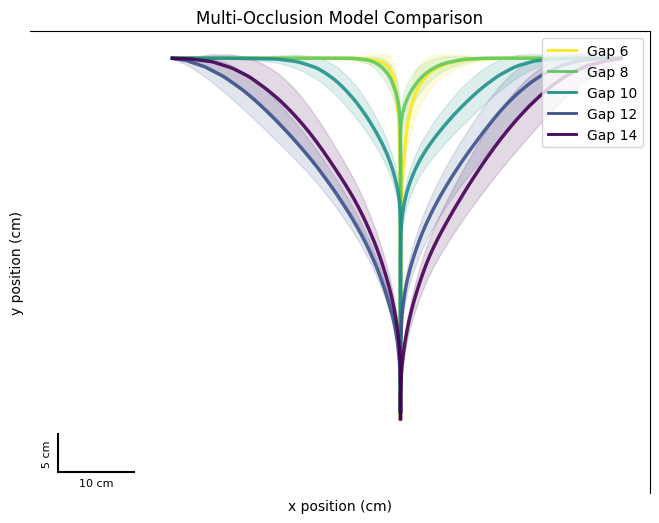


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.34
  Right trials: Success Rate = 1.00, Avg Reward = 1.25
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.58
  Right trials: Success Rate = 1.00, Avg Reward = 1.55
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.67
  Right trials: Success Rate = 1.00, Avg Reward = 1.64
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.66
  Right trials: Success Rate = 1.00, Avg Reward = 1.67
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.73
  Right trials: Success Rate = 1.00, Avg Reward = 1.72
  Overall Success Rate = 1.00



In [ ]:
# Check if we have any valid models
valid_models = [m for m in models if m is not None]
valid_gaps = [gap for gap, model in zip(gaps, models) if model is not None]
valid_envs = [env for env, model in zip(envs, models) if model is not None]
valid_info_matrices = [info for info, model in zip(info_matrices, models) if model is not None]
valid_colors = [colors_multi_aperture[i] for i, model in enumerate(models) if model is not None]


# Compare all valid models
print(f"Comparing {len(valid_models)} models...")
compare_models_multi_gaps(
    models=valid_models,
    envs=valid_envs, 
    info_matrices=valid_info_matrices,
    gaps=valid_gaps,
    trials_per_condition=100,
    colors_multi_aperture=valid_colors,
    save_path=f"final_multi_gap_comparison_epoch.svg",
    figure_title=f"Multi-Occlusion Model Comparison"
)


In [26]:

for model, gap in zip(valid_models, valid_gaps):
    model_path = f"./final_mouse_navigation_modelw{gap}"
    model.save(model_path)
    print(f"Final model for gap {gap} saved to {model_path}")



Final model for gap 6 saved to ./final_mouse_navigation_modelw6
Final model for gap 8 saved to ./final_mouse_navigation_modelw8
Final model for gap 10 saved to ./final_mouse_navigation_modelw10
Final model for gap 12 saved to ./final_mouse_navigation_modelw12
Final model for gap 14 saved to ./final_mouse_navigation_modelw14
